# Federated Image Classification with ResNet-18 (Using Dirichlet Distribution to create Non IID datasets)

In [2]:
!pip install torch torchvision -q

## Importing Required Libraries

This section imports the libraries required for building the Federated Learning pipeline.

The notebook mainly uses:

- PyTorch for deep learning
- Torchvision for datasets and transforms
- NumPy for numerical operations
- Matplotlib for plotting results

These libraries together help in model training, client simulation, and evaluation.

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import resnet18

from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import gc

## Configuring the Training Device

This cell checks whether CUDA is available.

If a GPU is detected, training is performed on the GPU; otherwise, the CPU is used.

Using a GPU significantly speeds up deep learning training, especially for convolutional neural networks like ResNet-18.

In [7]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Using Device: cuda
GPU: Tesla T4


## Defining Federated Learning Hyperparameters

This section defines the main training settings used throughout the experiment.

Some important parameters include:

- Number of clients
- Clients selected per round
- Number of communication rounds
- Local epochs
- Batch size
- Learning rate

These values directly affect convergence speed, communication cost, and overall model performance.

In [8]:
NUM_CLIENTS = 20

CLIENTS_PER_ROUND = 4

ROUNDS = 25

LOCAL_EPOCHS = 1

BATCH_SIZE = 16

LEARNING_RATE = 0.0003

## Applying Image Transformations

Before training, the images are preprocessed using augmentation and normalization techniques.

The training data uses:

- Random cropping
- Horizontal flipping
- Normalization

These transformations help improve generalization and reduce overfitting.

---

## Normalization

Pixel values are normalized using:   $x' = \frac{x - \mu}{\sigma}$


where:

- $\mu$ is the dataset mean
- $\sigma$ is the standard deviation

In [9]:
transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# Loading the CIFAR-100 Dataset

## What this code does
This cell downloads and loads:
- Training dataset
- Testing dataset

using the CIFAR-100 dataset from Torchvision.

## About CIFAR-100
CIFAR-100 contains:
- 60,000 color images
- 100 different classes
- 32×32 image size

## Dataset Split
- 50,000 training images
- 10,000 testing images

## Why this dataset is used
CIFAR-100 is commonly used for:
- Image classification research
- Federated Learning experiments
- Deep learning benchmarking

Its large number of classes makes the learning task more challenging.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
dataset_path = "/content/drive/MyDrive/FL_Project/datasets"

In [11]:


train_dataset = datasets.CIFAR100(
    root=dataset_path,
    train=True,
    download=False,
    transform=transform_train
)

test_dataset = datasets.CIFAR100(
    root=dataset_path,
    train=False,
    download=False,
    transform=transform_test
)

print("Training Samples:", len(train_dataset))

print("Testing Samples:", len(test_dataset))

Training Samples: 50000
Testing Samples: 10000


# Non-IID Client Data Distribution using Dirichlet Split

In real-world Federated Learning systems, client data is rarely Independent and Identically Distributed (IID). Different clients may contain different class distributions depending on user behavior, location, or device usage patterns.

To simulate this realistic scenario, we partition the CIFAR-100 dataset among clients using a Dirichlet distribution.

For each class, the sample proportions assigned to different clients are drawn from a Dirichlet distribution:

$$
(p_1, p_2, \dots, p_K) \sim \text{Dir}(\alpha)
$$

Where:
- $K$ is the number of clients
- $p_k$ represents the fraction of samples assigned to client $k$
- $\alpha$ controls the level of heterogeneity

### Effect of Alpha (\(\alpha\))

- Small $\alpha$ (e.g. 0.1):
  - Highly Non-IID distribution
  - Clients specialize in a few classes

- Large $\alpha$ (e.g. 10):
  - Nearly IID distribution
  - Class distributions become more uniform

In this experiment, Dirichlet partitioning creates realistic heterogeneous client datasets for Federated Learning training.

In [12]:
import numpy as np
from torch.utils.data import Subset

def create_dirichlet_noniid_clients(dataset, num_clients, alpha=0.5):
    """
    Creates Non-IID client datasets using Dirichlet distribution.

    Args:
        dataset: PyTorch dataset
        num_clients: Number of federated clients
        alpha: Dirichlet concentration parameter
               Smaller alpha -> more Non-IID
               Larger alpha  -> more IID

    Returns:
        client_datasets: List of PyTorch Subsets
    """

    labels = np.array(dataset.targets)
    num_classes = len(np.unique(labels))

    # Store indices for each client
    client_indices = [[] for _ in range(num_clients)]

    # Process each class separately
    for cls in range(num_classes):

        # Get all indices of current class
        cls_indices = np.where(labels == cls)[0]

        # Shuffle indices
        np.random.shuffle(cls_indices)

        # Generate Dirichlet proportions
        proportions = np.random.dirichlet(
            alpha=[alpha] * num_clients
        )

        # Convert proportions into split sizes
        split_sizes = (proportions * len(cls_indices)).astype(int)

        # Fix rounding issue
        split_sizes[-1] = len(cls_indices) - np.sum(split_sizes[:-1])

        # Split indices according to proportions
        split_indices = np.split(
            cls_indices,
            np.cumsum(split_sizes)[:-1]
        )

        # Assign to clients
        for client_id in range(num_clients):
            client_indices[client_id].extend(
                split_indices[client_id].tolist()
            )

    # Shuffle client data
    for client_id in range(num_clients):
        np.random.shuffle(client_indices[client_id])

    # Create PyTorch subsets
    client_datasets = [
        Subset(dataset, indices)
        for indices in client_indices
    ]

    return client_datasets

# Generating Federated Clients

## What this code does
This cell creates all client datasets using the previously defined Non-IID partitioning function.

## Output
- 20 simulated clients are created
- Each client contains a different subset of CIFAR-100 classes

## Why this is important
Federated Learning requires:
- Multiple decentralized clients
- Independent local datasets

This step simulates distributed user data.

In [13]:
client_datasets = create_dirichlet_noniid_clients(
    train_dataset,
    NUM_CLIENTS
)

print("\nCreated Non-IID Clients")


Created Non-IID Clients


In [14]:
from collections import Counter
import numpy as np

# CIFAR-100 class names
class_names = train_dataset.classes

for client_id, client_data in enumerate(client_datasets):

    # Get labels of samples in this client
    labels = [train_dataset.targets[idx] for idx in client_data.indices]

    # Count class occurrences
    class_count = Counter(labels)

    print(f"\nClient {client_id}")
    print("-" * 40)

    for cls, count in sorted(class_count.items()):

        print(f"{class_names[cls]:20s}: {count}")


Client 0
----------------------------------------
apple               : 6
baby                : 12
bear                : 4
beaver              : 44
bed                 : 112
bee                 : 5
beetle              : 50
bridge              : 10
bus                 : 81
butterfly           : 38
can                 : 47
castle              : 38
caterpillar         : 21
cattle              : 25
chair               : 5
chimpanzee          : 14
clock               : 13
cloud               : 1
cockroach           : 2
couch               : 22
crab                : 43
crocodile           : 1
cup                 : 3
dinosaur            : 49
elephant            : 43
flatfish            : 17
forest              : 6
fox                 : 30
girl                : 67
hamster             : 200
keyboard            : 8
lamp                : 84
lawn_mower          : 107
leopard             : 15
lion                : 1
lizard              : 70
lobster             : 96
man                 : 70
maple_t

# Initializing the Global ResNet-18 Model

This section initializes the global model used for Federated Learning.

The architecture used is ResNet-18, which introduces residual connections to improve deep network training.

---

## Residual Learning

Instead of learning a direct mapping, ResNet learns: $H(x) = F(x) + x$

where:

- $F(x)$ is the residual mapping
- $x$ is the shortcut connection

These skip connections help reduce the vanishing gradient problem in deep neural networks.

In [15]:
global_model = resnet18(
    num_classes=100
).to(DEVICE)

print("Global Model Initialized")

Global Model Initialized


## Local Client Training

This function performs local training on a client's private dataset.

Each client independently updates the model parameters using gradient descent.



## Local Weight Update

The model parameters are updated as:


$\theta_{t+1} =
\theta_t - \eta \nabla \mathcal{L}(\theta_t)$

where:

- $\eta$ is the learning rate
- $\mathcal{L}$ is the loss function
- $\nabla \mathcal{L}$ represents the gradient

Only the updated model weights are sent back to the server.

In [21]:
def train_client(model, dataset):

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=1,
        gamma=0.9
    )

    model.train()

    total_loss = 0

    for epoch in range(LOCAL_EPOCHS):

        epoch_loss = 0

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        scheduler.step()

        avg_epoch_loss = (
            epoch_loss / len(loader)
        )

        total_loss += avg_epoch_loss

    avg_client_loss = (
        total_loss / LOCAL_EPOCHS
    )

    return model.state_dict(), avg_client_loss

## Federated Averaging (FedAvg)

After local training, the server aggregates the client models into a new global model.

This aggregation is performed using the Federated Averaging algorithm.

---

## FedAvg Equation

The updated global model is computed as:

$w^{(t+1)} =
\sum_{k=1}^{K}
\frac{n_k}{n}
w_k^{(t)}$

where:

- $w_k^{(t)}$ represents the weights from client $k$
- $n_k$ is the number of samples in client $k$
- $n$ is the total number of samples across all selected clients

This allows collaborative learning without sharing raw user data.

In [22]:
def federated_average(client_weights):

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack([
            client_weights[i][key].float()
            for i in range(len(client_weights))
        ], dim=0).mean(dim=0)

    global_model.load_state_dict(global_dict)

    return global_model

## Evaluating the Global Model

This section evaluates the updated global model on the test dataset.

The performance is measured using classification accuracy.


## Accuracy Formula

$\text{Accuracy} =
\frac{\text{Correct Predictions}}
{\text{Total Samples}}
\times 100$

Higher accuracy indicates better generalization performance.

In [23]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

def evaluate_model(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = 100 * correct / total

    return accuracy

# Federated Learning Training Process

This is the main communication loop of the Federated Learning system.

Each communication round consists of:

1. Selecting clients
2. Local client training
3. Server aggregation
4. Global evaluation

---

## Global Aggregation

The server updates the global model using:

$w^{(t+1)} =
\sum_{k \in S_t}
\frac{n_k}{n}
w_k^{(t+1)}$

\
The updated global weights are then broadcast back to clients for the next round.

In [24]:
round_accuracies = []
round_losses = []

best_accuracy = 0

best_model_weights = None

for round_num in range(ROUNDS):

    start_time = time.time()

    print("=" * 70)
    print(f"ROUND {round_num+1}/{ROUNDS}")
    print("=" * 70)

    selected_clients = np.random.choice(
        NUM_CLIENTS,
        CLIENTS_PER_ROUND,
        replace=False
    )

    print("Selected Clients:", selected_clients)

    client_weights = []
    client_losses = []

    for client_id in selected_clients:

        print(f"\nTraining Client {client_id}...")

        local_model = resnet18(
            num_classes=100
        ).to(DEVICE)

        local_model.load_state_dict(
            global_model.state_dict()
        )

        weights, loss = train_client(
            local_model,
            client_datasets[client_id]
        )

        client_weights.append(weights)
        client_losses.append(loss)

        print(
            f"Client {client_id} "
            f"Loss: {loss:.4f}"
        )

        del local_model

        torch.cuda.empty_cache()

        gc.collect()

    federated_average(client_weights)

    avg_loss = (
        sum(client_losses)
        / len(client_losses)
    )

    accuracy = evaluate_model(global_model)

    round_accuracies.append(accuracy)

    round_losses.append(avg_loss)

    if round_num == 0:
        accuracy_change = accuracy
    else:
        accuracy_change = (
            accuracy
            - round_accuracies[-2]
        )

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model_weights = copy.deepcopy(
            global_model.state_dict()
        )

    round_time = (
        time.time() - start_time
    )

    print("\n" + "=" * 70)
    print("ROUND SUMMARY")
    print("=" * 70)

    print(
        f"Average Client Loss : "
        f"{avg_loss:.4f}"
    )

    print(
        f"Global Accuracy     : "
        f"{accuracy:.2f}%"
    )

    print(
        f"Accuracy Change     : "
        f"{accuracy_change:+.2f}%"
    )

    print(
        f"Best Accuracy       : "
        f"{best_accuracy:.2f}%"
    )

    print(
        f"Round Duration      : "
        f"{round_time:.2f} sec"
    )

    print("=" * 70)
    print()

ROUND 1/25
Selected Clients: [17 10  6 19]

Training Client 17...
Client 17 Loss: 3.4027

Training Client 10...
Client 10 Loss: 3.5144

Training Client 6...
Client 6 Loss: 3.5583

Training Client 19...
Client 19 Loss: 3.7753

ROUND SUMMARY
Average Client Loss : 3.5627
Global Accuracy     : 10.77%
Accuracy Change     : +10.77%
Best Accuracy       : 10.77%
Round Duration      : 20.01 sec

ROUND 2/25
Selected Clients: [ 0 13 19  2]

Training Client 0...
Client 0 Loss: 3.3090

Training Client 13...
Client 13 Loss: 3.3508

Training Client 19...
Client 19 Loss: 3.6452

Training Client 2...
Client 2 Loss: 3.3482

ROUND SUMMARY
Average Client Loss : 3.4133
Global Accuracy     : 13.42%
Accuracy Change     : +2.65%
Best Accuracy       : 13.42%
Round Duration      : 20.64 sec

ROUND 3/25
Selected Clients: [15 13  7  1]

Training Client 15...
Client 15 Loss: 3.0370

Training Client 13...
Client 13 Loss: 3.1905

Training Client 7...
Client 7 Loss: 3.2889

Training Client 1...
Client 1 Loss: 3.3467


# Restoring the Best Global Model

## What this code does
This cell reloads the best-performing model obtained during training.

## Why this is important
During training:
- Accuracy may fluctuate
- Later rounds may reduce performance

Restoring the best model ensures:
- Highest achieved accuracy is preserved
- Final evaluation uses the optimal model

In [25]:
global_model.load_state_dict(
    best_model_weights
)

print("Best Model Restored")

print(
    f"Best Accuracy: "
    f"{best_accuracy:.2f}%"
)

Best Model Restored
Best Accuracy: 26.03%


## Visualizing Global Accuracy

This graph shows how the global model accuracy changes across communication rounds.

An increasing accuracy trend generally indicates improved global learning and better collaboration between clients.

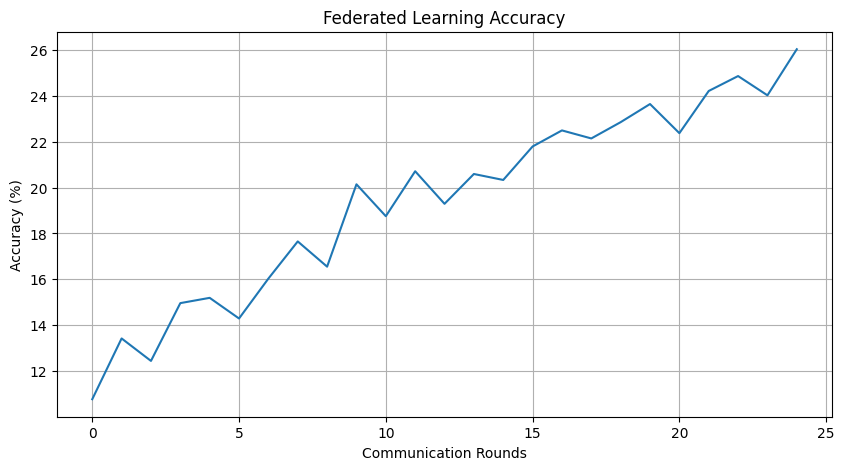

In [26]:
plt.figure(figsize=(10,5))

plt.plot(round_accuracies)

plt.xlabel("Communication Rounds")

plt.ylabel("Accuracy (%)")

plt.title(
    "Federated Learning Accuracy"
)

plt.grid(True)

plt.show()

## Visualizing Training Loss

This plot tracks the average client training loss during Federated Learning.

Lower loss values generally indicate better convergence during training.

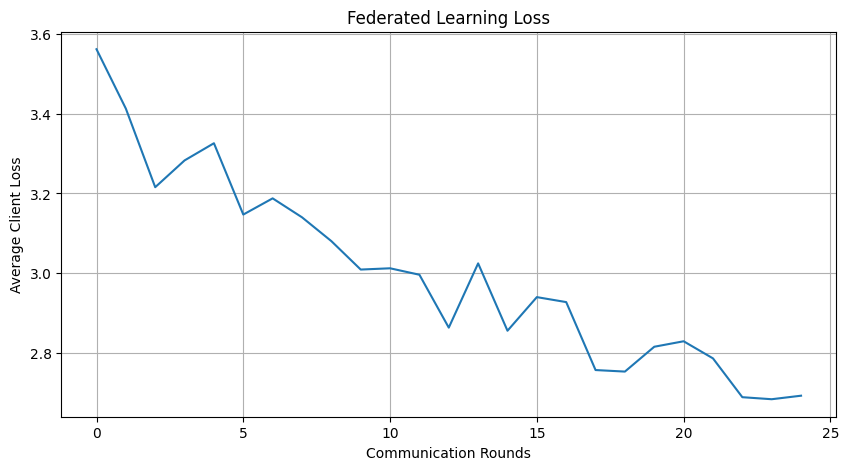

In [27]:
plt.figure(figsize=(10,5))

plt.plot(round_losses)

plt.xlabel("Communication Rounds")

plt.ylabel("Average Client Loss")

plt.title(
    "Federated Learning Loss"
)

plt.grid(True)

plt.show()

## Conclusion

This experiment successfully implemented a Federated Learning framework on the CIFAR-100 dataset using a ResNet-18 model under a Dirichlet-based Non-IID data distribution. The results showed steady improvement in global model performance across communication rounds, with the global accuracy increasing from **10.77%** in the first round to **26.03%** after 25 rounds.

Although fluctuations in accuracy were observed during training, this behavior is expected in Non-IID Federated Learning environments where clients possess highly heterogeneous data distributions. The gradual reduction in client loss and overall increase in accuracy demonstrate that the FedAvg algorithm was able to effectively aggregate decentralized client updates and achieve global learning convergence.

Overall, the experiment highlights both the effectiveness and the challenges of Federated Learning under realistic Non-IID conditions. The results indicate that while decentralized learning can successfully train a global model without centralized data sharing, data heterogeneity significantly impacts convergence speed and final model performance.